Job title counts in merged data:
job_title
data analyst    140
Name: count, dtype: int64
Merged dataset shape: (140, 17)
First 5 rows:
                       date company     job_title location  \
0 2025-04-26 16:00:02+00:00     KPA  data analyst   Remote   
1 2025-04-26 16:00:02+00:00     KPA  data analyst   Remote   
2 2025-04-26 16:00:02+00:00     KPA  data analyst   Remote   
3 2025-04-26 16:00:02+00:00     KPA  data analyst   Remote   
4 2025-04-26 16:00:02+00:00     KPA  data analyst   Remote   

                                              skills  salary_min  salary_max  \
0  [analyst, saas, salesforce, training, consulti...       70000      115000   
1  [analyst, saas, salesforce, training, consulti...       70000      115000   
2  [analyst, saas, salesforce, training, consulti...       70000      115000   
3  [analyst, saas, salesforce, training, consulti...       70000      115000   
4  [analyst, saas, salesforce, training, consulti...       70000      115000   

   work_yea

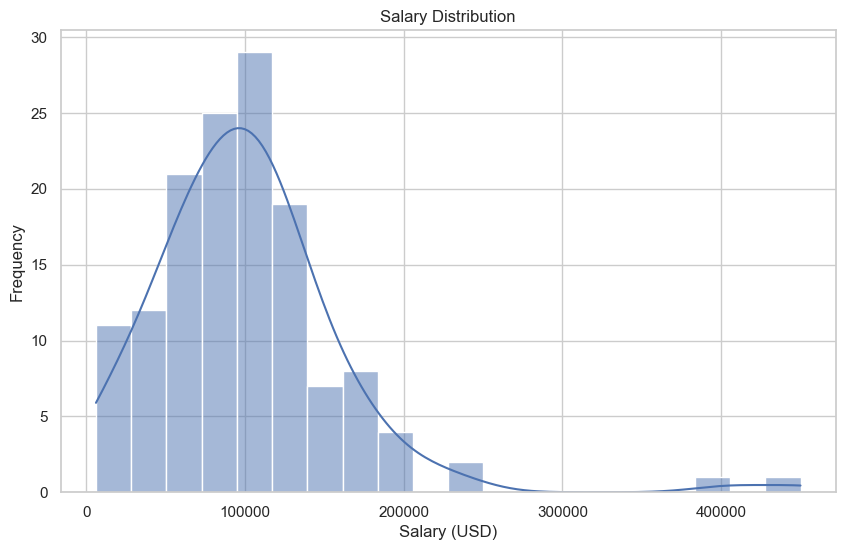

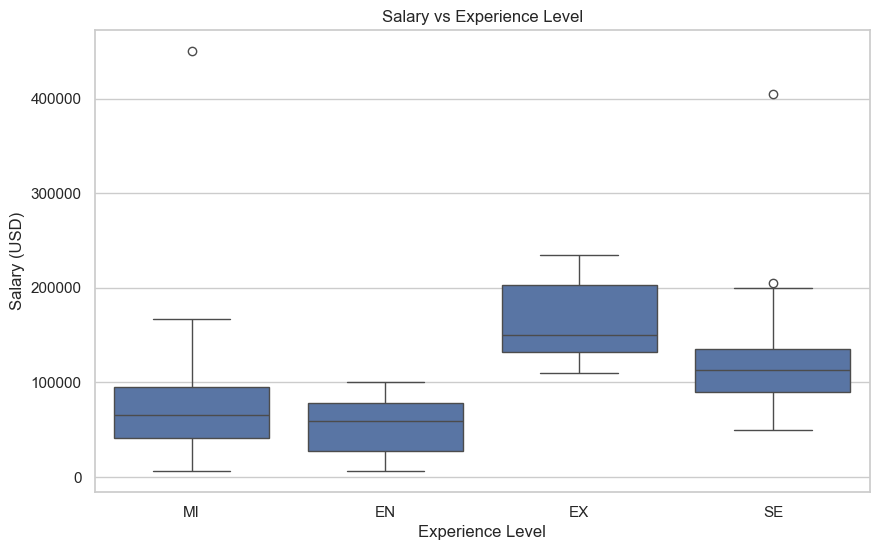

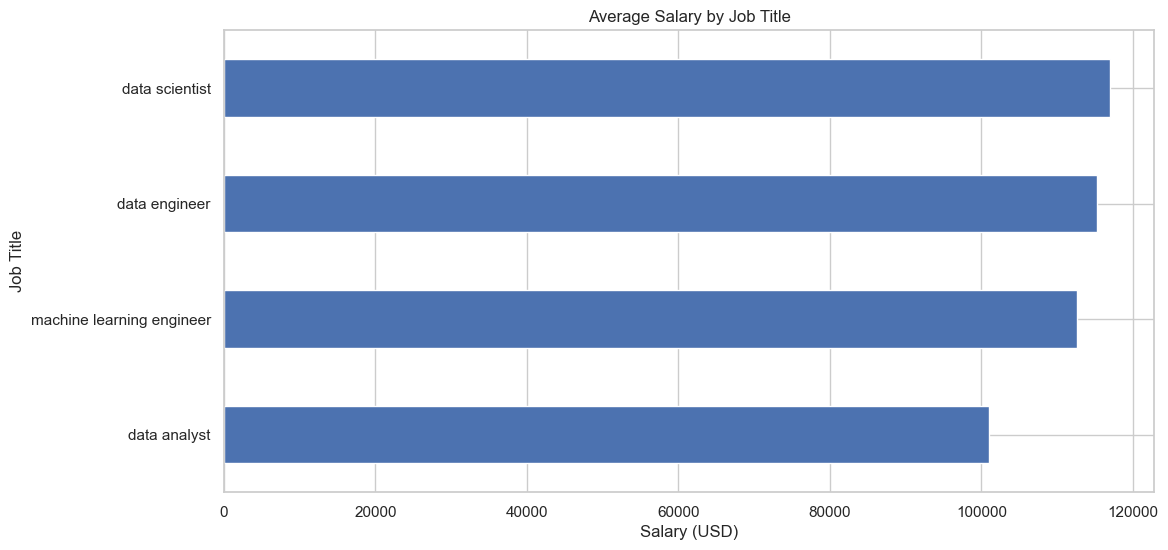

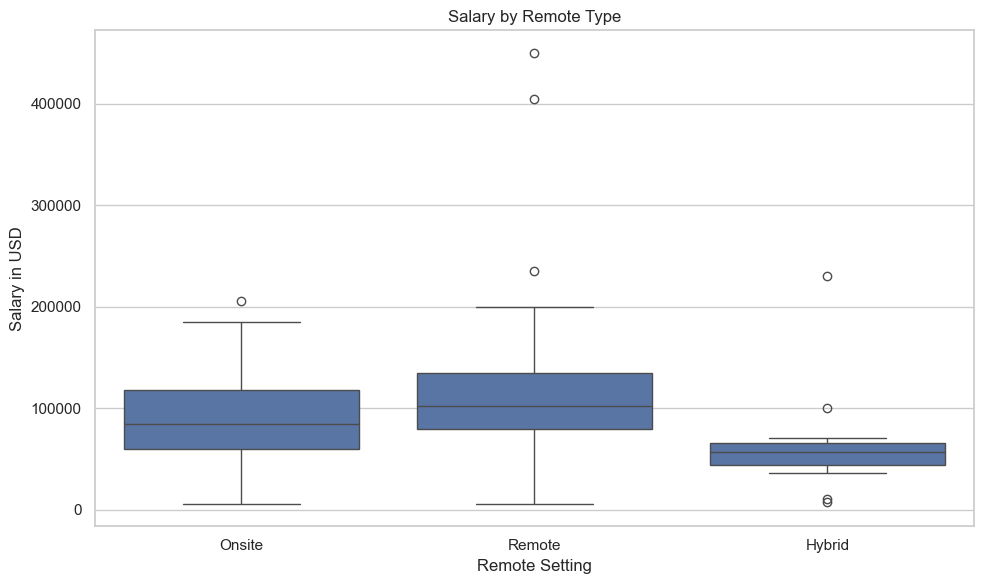

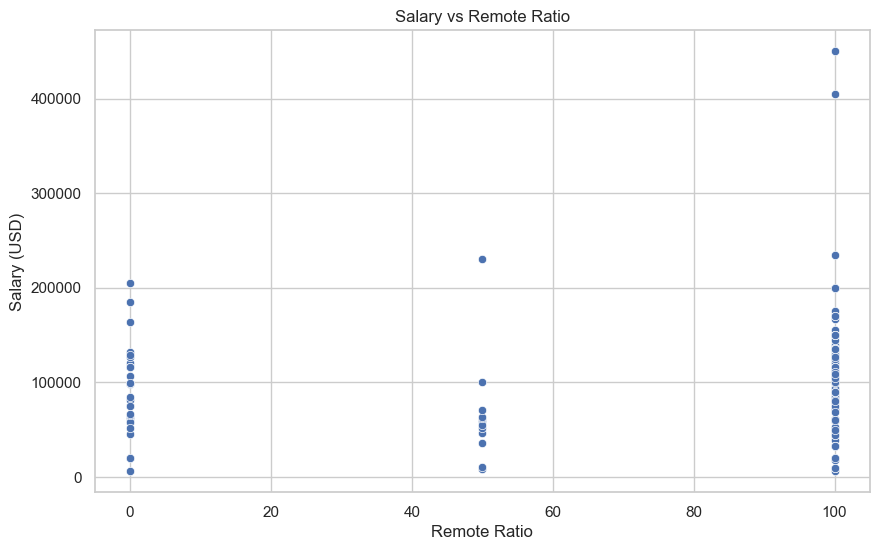

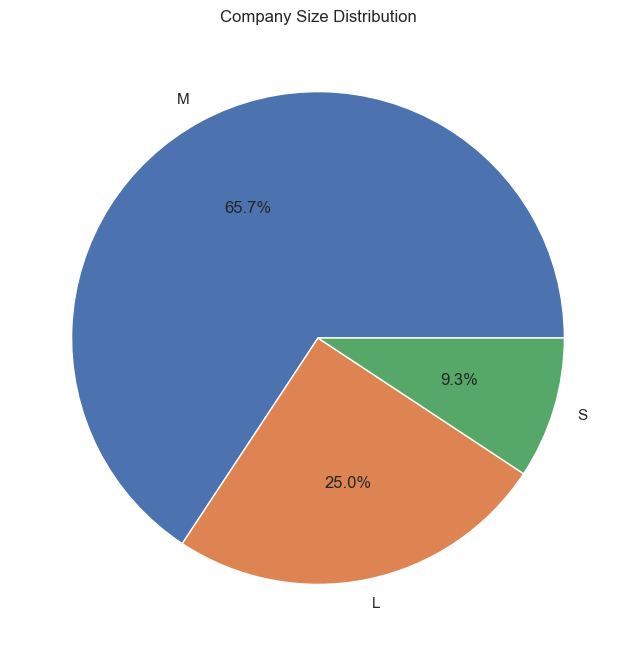

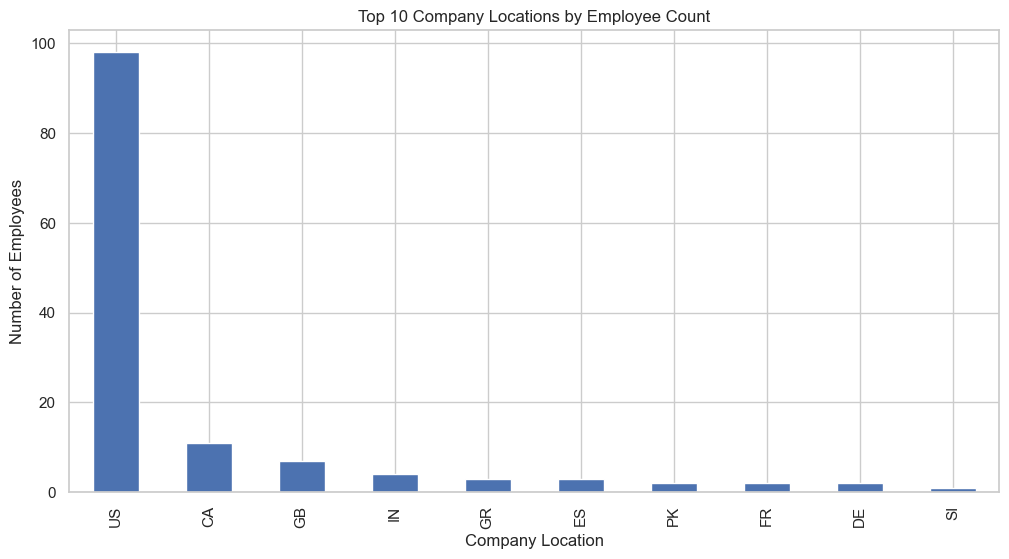

<Figure size 1000x600 with 0 Axes>

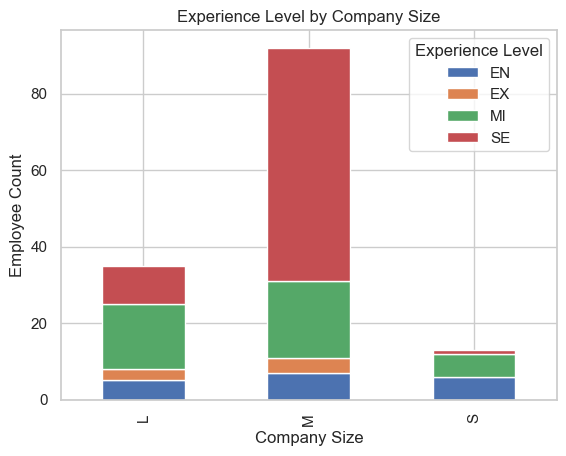


Top 15 Meaningful Skills:
skills
blockchain      31
finance         22
javascript      15
cloud           14
security        14
analytics       11
testing         10
backend         10
saas             9
frontend         8
salesforce       7
fintech          7
web              7
devops           7
social media     6
Name: count, dtype: int64


C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_40700\3816044303.py:220: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='deep')


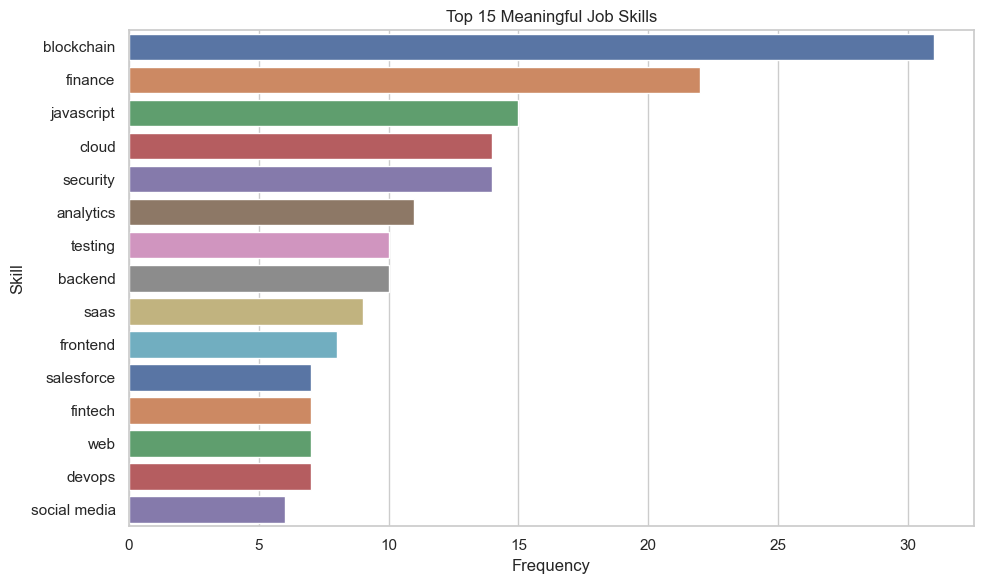

In [33]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load API Data ---
url = "https://remoteok.com/api"
response = requests.get(url)
data = response.json()
df_api = pd.DataFrame(data[1:])

df_api = df_api[[
    'date', 'company', 'position', 'location', 'tags',
    'salary_min', 'salary_max'
]].copy()

df_api.rename(columns={
    'position': 'job_title',
    'tags': 'skills',
}, inplace=True)

df_api['date'] = pd.to_datetime(df_api['date'], errors='coerce')
df_api['salary_min'] = pd.to_numeric(df_api['salary_min'], errors='coerce')
df_api['salary_max'] = pd.to_numeric(df_api['salary_max'], errors='coerce')

# --- Load CSV Data ---
df_salary = pd.read_csv(r"C:\Users\Mahmoud Gobran\Downloads\salary_dataset.csv")

# Normalize job titles
df_api['job_title'] = df_api['job_title'].str.lower().str.strip().str.replace('-', ' ')
df_salary['job_title'] = df_salary['job_title'].str.lower().str.strip().str.replace('-', ' ')

job_title_map = {
    'data analyst': 'data analyst',
    'junior data analyst': 'data analyst',
    'senior data analyst': 'data analyst',
    'data analytics specialist': 'data analyst',
    
    'data scientist': 'data scientist',
    'senior data scientist': 'data scientist',
    'junior data scientist': 'data scientist',
    
    'data engineer': 'data engineer',
    'senior data engineer': 'data engineer',
    'data analytics engineer': 'data engineer',
    
    'ml engineer': 'machine learning engineer',
    'machine learning engineer': 'machine learning engineer',
    'machine learning developer': 'machine learning engineer',
    'ai engineer': 'machine learning engineer',
    'ai ml engineer': 'machine learning engineer'
}

df_api['job_title'] = df_api['job_title'].replace(job_title_map)
df_salary['job_title'] = df_salary['job_title'].replace(job_title_map)

# --- Merge Datasets ---
df_api['job_title'] = df_api['job_title'].str.lower().str.strip()
df_salary['job_title'] = df_salary['job_title'].str.lower().str.strip()
df_merged = pd.merge(df_api, df_salary, on='job_title', how='inner')

print("Job title counts in merged data:")
print(df_merged['job_title'].value_counts())

print("Merged dataset shape:", df_merged.shape)
print("First 5 rows:")
print(df_merged.head())

print("\nColumn info:")
print(df_merged.info())

print("\nMissing values:")
print(df_merged.isnull().sum())

print("\nNumerical stats:")
print(df_merged.describe())

categorical_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]
for col in categorical_cols:
    print(f"\n{col} values:")
    print(df_merged[col].unique())

print("\nUnique Job Titles:")
print(df_merged['job_title'].unique())

print("\nSalary Range by Job Title:")
print(df_merged.groupby('job_title')['salary_in_usd'].agg(['min', 'max']))

print("\nAverage Salary by Experience:")
print(df_merged.groupby('experience_level')['salary_in_usd'].mean())

print("\nEmployee Count by Company Size:")
print(df_merged['company_size'].value_counts())

print("\nAverage Remote Ratio:")
print(df_merged['remote_ratio'].mean())

print("\nTop 5 Countries by Employee Count:")
print(df_merged['employee_residence'].value_counts().head(5))

print("\nSalary vs Remote Ratio Correlation:")
print(df_merged['salary_in_usd'].corr(df_merged['remote_ratio']))

print("\nAverage Salary by Company Location:")
print(df_merged.groupby('company_location')['salary_in_usd'].mean())

print("\nExperience Level Distribution:")
print(df_merged['experience_level'].value_counts())

print("\nAverage Salary by Job Title:")
print(df_merged.groupby('job_title')['salary_in_usd'].mean())

# --- Visualizations ---
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['salary_in_usd'], bins=20, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df_merged)
plt.title('Salary vs Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

plt.figure(figsize=(12, 6))
df_salary.groupby('job_title')['salary_in_usd'].mean().sort_values().plot(kind='barh')
plt.title('Average Salary by Job Title')
plt.xlabel('Salary (USD)')
plt.ylabel('Job Title')
plt.show()

remote_map = {0: 'Onsite', 50: 'Hybrid', 100: 'Remote'}
df_merged['remote_type'] = df_merged['remote_ratio'].map(remote_map)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_merged, x='remote_type', y='salary_in_usd')
plt.title('Salary by Remote Type')
plt.xlabel('Remote Setting')
plt.ylabel('Salary in USD')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='remote_ratio', y='salary_in_usd', data=df_merged)
plt.title('Salary vs Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary (USD)')
plt.show()

plt.figure(figsize=(8, 8))
df_merged['company_size'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Company Size Distribution')
plt.ylabel('')
plt.show()

plt.figure(figsize=(12, 6))
df_merged['company_location'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Company Locations by Employee Count')
plt.xlabel('Company Location')
plt.ylabel('Number of Employees')
plt.show()

plt.figure(figsize=(10, 6))
pd.crosstab(df_merged['company_size'], df_merged['experience_level']).plot(kind='bar', stacked=True)
plt.title('Experience Level by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Employee Count')
plt.legend(title='Experience Level')
plt.show()

# --- Skills Analysis ---

# Explode all skills into a flat list
all_skills = df_api['skills'].dropna().explode()
all_skills = all_skills.str.lower().str.strip()

# Define generic, broad, and unclear terms to remove
junk_skills = set([
    'remote', 'job', 'full time', 'full-time', 'contract', 'part time', 'digital nomad',
    'management', 'manager', 'lead', 'leader', 'non tech', 'technical', 'support', 
    'developer', 'engineer', 'engineering', 'software', 'consulting', 'admin', 'growth', 'dev',
    'senior', 'operations', 'training', 'sales', 'strategy', 'health', 'content', 'marketing',
    'finance', 'design', 'code', 'system', 'travel', 'operational', 'legal', 'voice', 'education'
])

filtered_skills = all_skills[~all_skills.isin(junk_skills)]

# Normalize skill names
skill_map = {
    'js': 'javascript',
    'py': 'python',
    'node': 'nodejs',
    'reactjs': 'react',
    'typescript': 'javascript',
    'html5': 'html',
    'css3': 'css',
    'amazon': 'aws',
    'heroku': 'cloud',
    'web3': 'blockchain',
    'crypto': 'blockchain',
    'cryptocurrency': 'blockchain',
    'defi': 'blockchain',
    'investment': 'finance',
    'financial': 'finance'
}
filtered_skills = filtered_skills.replace(skill_map)

top_skills = filtered_skills.value_counts().head(15)

print("\nTop 15 Meaningful Skills:")
print(top_skills)

plt.figure(figsize=(10,6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='deep')
plt.title("Top 15 Meaningful Job Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


In [35]:
print("Mapped job titles in df_api:")
print(df_api['job_title'].value_counts())


Mapped job titles in df_api:
job_title
senior software engineer              2
web3 marketing manager                2
sales development representative      2
account executive                     2
lead backend engineer debugger        1
                                     ..
digital editorial manager             1
senior data analytics engineer        1
support specialist                    1
mid market sales account executive    1
manager maintenance                   1
Name: count, Length: 91, dtype: int64


In [36]:
print("API job titles:", df_api['job_title'].unique())
print("CSV job titles:", df_salary['job_title'].unique())


API job titles: ['manager engineering ii data pipelines' 'visual designer'
 'marketing design intern 2025 summer intern'
 'lifecycle marketing associate' 'member of product trading'
 'associate attorney' '' 'member support unicorn'
 'staff frontend engineer' 'staff machine learning engineer' 'recruiter'
 'social media expert' 'app designer' 'full stack software engineer'
 'testing engineer' 'accountant' 'commercial content editor'
 'salesforce engineer' 'account coordinator' 'head of growth'
 'werkstudent im bereich sap &amp; cloud automation'
 'senior golang engineer' 'software engineering team lead'
 'salesforce lead' 'mid market sales account executive'
 'support specialist' 'senior data analytics engineer'
 'digital editorial manager' 'senior fullstack software engineer'
 'investment manager' 'content writer' 'sales development representative'
 'sr software engineer cross platform applications'
 'sr software engineer backend web applications' 'web3 marketing manager'
 'smart contra

In [32]:
print("df_api job titles:", df_api['job_title'].value_counts())
print("df_salary job titles:", df_salary['job_title'].value_counts())
print("df_merged job titles:", df_merged['job_title'].value_counts())


df_api job titles: job_title
senior software engineer              2
web3 marketing manager                2
sales development representative      2
account executive                     2
lead backend engineer debugger        1
                                     ..
digital editorial manager             1
senior data analytics engineer        1
support specialist                    1
mid market sales account executive    1
manager maintenance                   1
Name: count, Length: 91, dtype: int64
df_salary job titles: job_title
data scientist               214
data engineer                191
data analyst                 140
machine learning engineer     62
Name: count, dtype: int64
df_merged job titles: job_title
data analyst    140
Name: count, dtype: int64


Job title counts in merged data:
job_title
data engineer                 1528
machine learning developer     186
data analyst                   140
Name: count, dtype: int64
Merged dataset shape: (1854, 17)
First 5 rows:
                       date   company      job_title location  \
0 2025-05-15 10:00:03+00:00  Notabene  data engineer            
1 2025-05-15 10:00:03+00:00  Notabene  data engineer            
2 2025-05-15 10:00:03+00:00  Notabene  data engineer            
3 2025-05-15 10:00:03+00:00  Notabene  data engineer            
4 2025-05-15 10:00:03+00:00  Notabene  data engineer            

                                              skills  salary_min  salary_max  \
0  [frontend, design, crypto, cryptocurrency, sys...       70000      110000   
1  [frontend, design, crypto, cryptocurrency, sys...       70000      110000   
2  [frontend, design, crypto, cryptocurrency, sys...       70000      110000   
3  [frontend, design, crypto, cryptocurrency, sys...       70000    

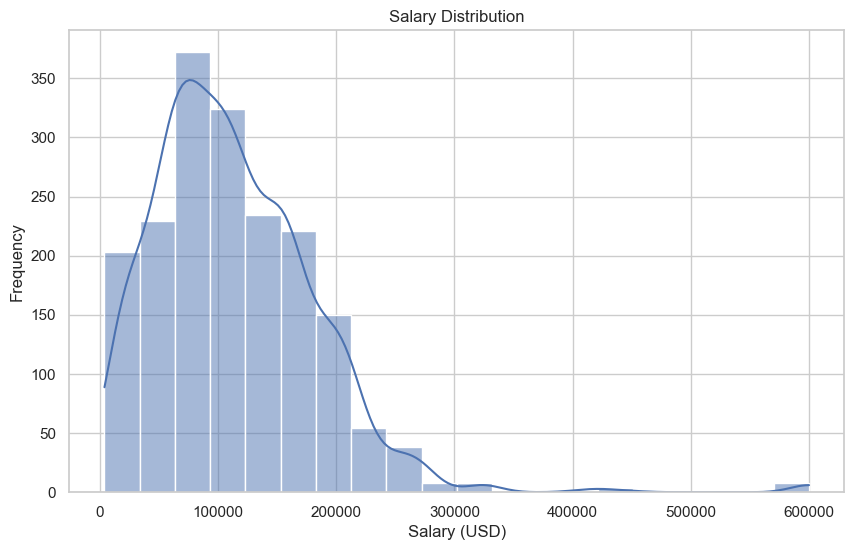

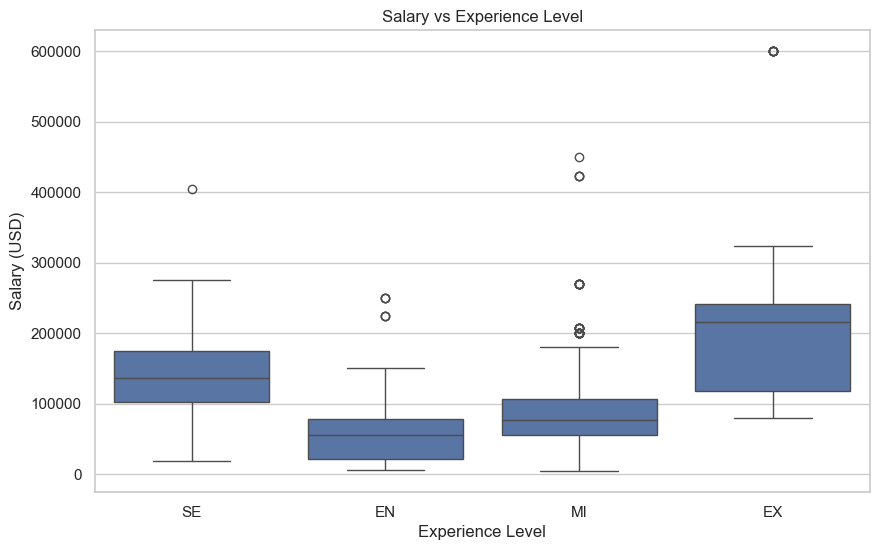

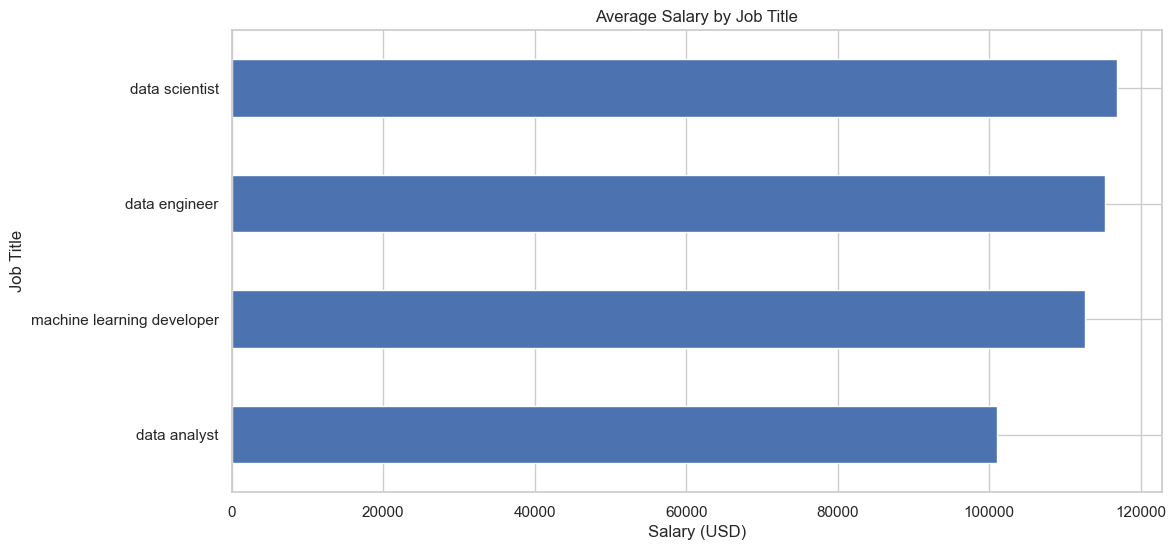

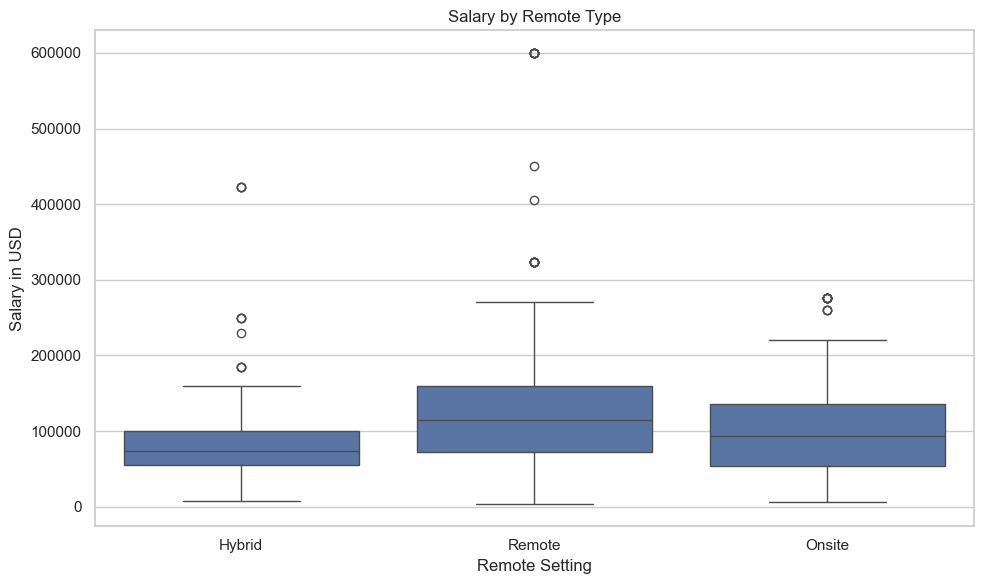

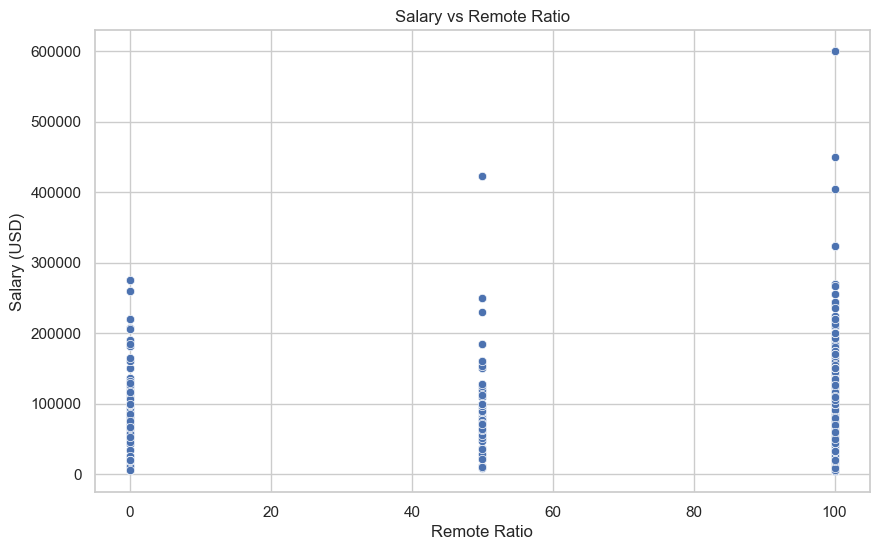

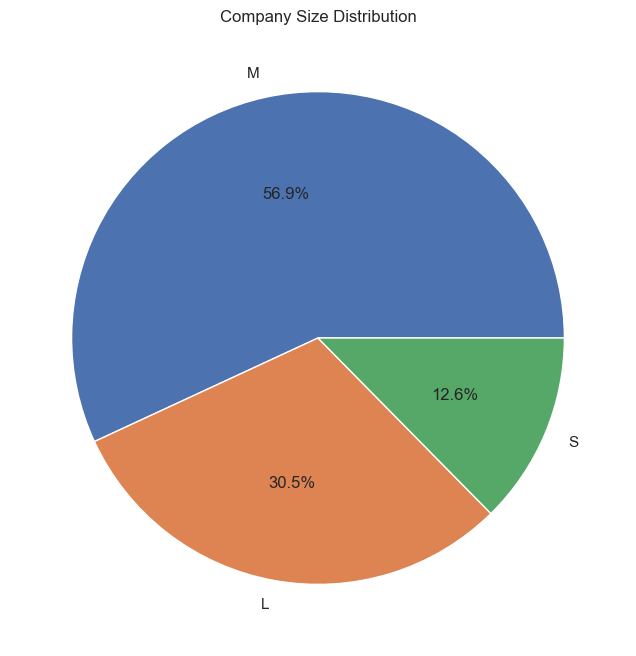

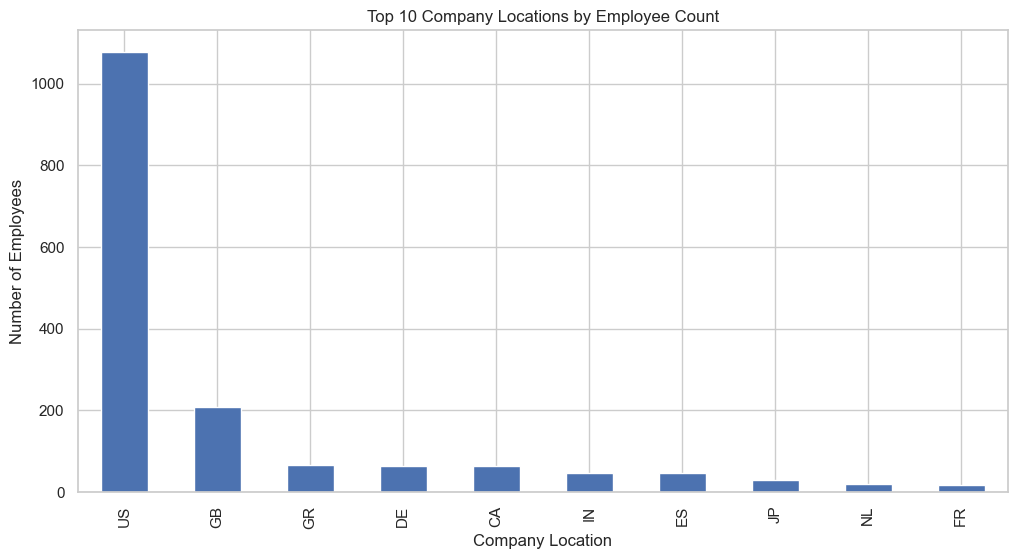

<Figure size 1000x600 with 0 Axes>

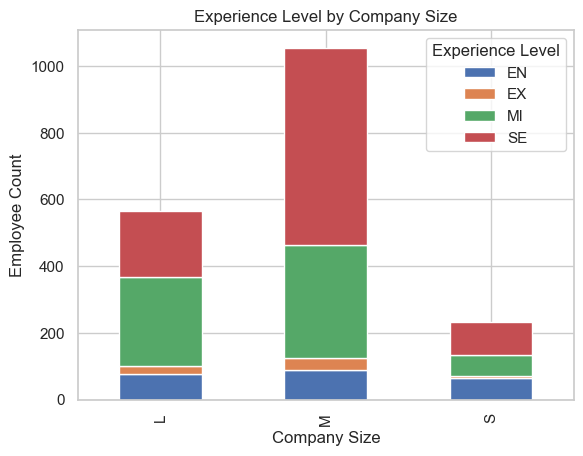


Top 15 Meaningful Skills:
skills
blockchain      31
finance         22
javascript      15
cloud           14
security        14
analytics       11
testing         10
backend         10
saas             9
frontend         8
salesforce       7
fintech          7
web              7
devops           7
social media     6
Name: count, dtype: int64


C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_40700\1903535089.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='deep')


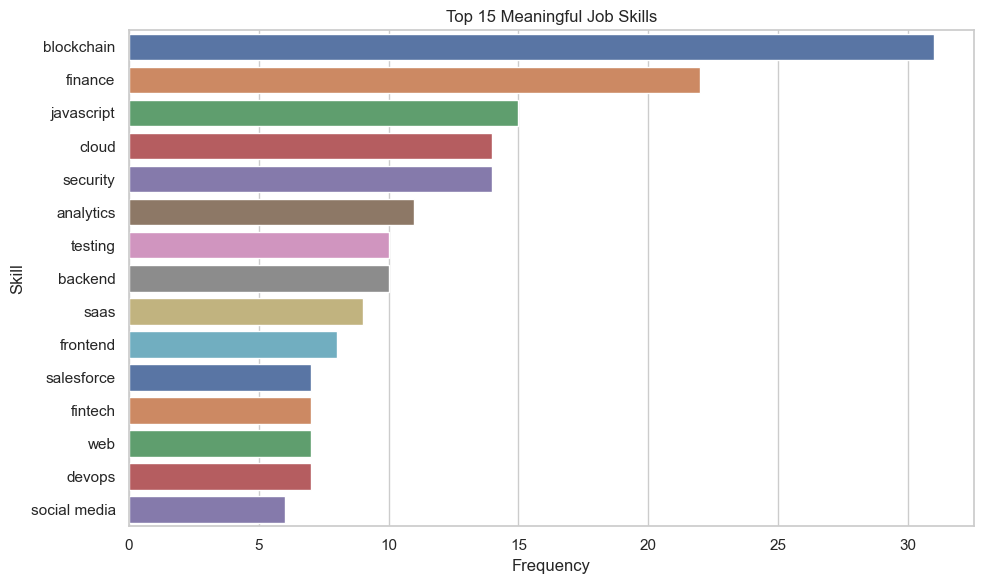

In [45]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import get_close_matches

# --- Load API Data ---
url = "https://remoteok.com/api"
response = requests.get(url)
data = response.json()
df_api = pd.DataFrame(data[1:])

df_api = df_api[[
    'date', 'company', 'position', 'location', 'tags',
    'salary_min', 'salary_max'
]].copy()

df_api.rename(columns={
    'position': 'job_title',
    'tags': 'skills',
}, inplace=True)

df_api['date'] = pd.to_datetime(df_api['date'], errors='coerce')
df_api['salary_min'] = pd.to_numeric(df_api['salary_min'], errors='coerce')
df_api['salary_max'] = pd.to_numeric(df_api['salary_max'], errors='coerce')

# --- Load CSV Data ---
df_salary = pd.read_csv(r"C:\Users\Mahmoud Gobran\Downloads\salary_dataset.csv")

# --- Normalize Job Titles ---
df_api['job_title'] = df_api['job_title'].str.lower().str.strip().str.replace('-', ' ')
df_salary['job_title'] = df_salary['job_title'].str.lower().str.strip().str.replace('-', ' ')

# --- Auto Match Job Titles Using Fuzzy Matching ---
api_titles = df_api['job_title'].unique()
salary_titles = df_salary['job_title'].unique()

job_title_map = {}

for title in api_titles:
    match = get_close_matches(title, salary_titles, n=1, cutoff=0.6)
    if match:
        job_title_map[title] = match[0]

df_api['job_title'] = df_api['job_title'].replace(job_title_map)

# --- Merge Datasets ---
df_api['job_title'] = df_api['job_title'].str.lower().str.strip()
df_salary['job_title'] = df_salary['job_title'].str.lower().str.strip()

df_merged = pd.merge(df_api, df_salary, on='job_title', how='inner')

print("Job title counts in merged data:")
print(df_merged['job_title'].value_counts())

print("Merged dataset shape:", df_merged.shape)
print("First 5 rows:")
print(df_merged.head())

print("\nColumn info:")
print(df_merged.info())

print("\nMissing values:")
print(df_merged.isnull().sum())

print("\nNumerical stats:")
print(df_merged.describe())

categorical_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]
for col in categorical_cols:
    print(f"\n{col} values:")
    print(df_merged[col].unique())

print("\nUnique Job Titles:")
print(df_merged['job_title'].unique())

print("\nSalary Range by Job Title:")
print(df_merged.groupby('job_title')['salary_in_usd'].agg(['min', 'max']))

print("\nAverage Salary by Experience:")
print(df_merged.groupby('experience_level')['salary_in_usd'].mean())

print("\nEmployee Count by Company Size:")
print(df_merged['company_size'].value_counts())

print("\nAverage Remote Ratio:")
print(df_merged['remote_ratio'].mean())

print("\nTop 5 Countries by Employee Count:")
print(df_merged['employee_residence'].value_counts().head(5))

print("\nSalary vs Remote Ratio Correlation:")
print(df_merged['salary_in_usd'].corr(df_merged['remote_ratio']))

print("\nAverage Salary by Company Location:")
print(df_merged.groupby('company_location')['salary_in_usd'].mean())

print("\nExperience Level Distribution:")
print(df_merged['experience_level'].value_counts())

print("\nAverage Salary by Job Title:")
print(df_merged.groupby('job_title')['salary_in_usd'].mean())

# --- Visualizations ---
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['salary_in_usd'], bins=20, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df_merged)
plt.title('Salary vs Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

plt.figure(figsize=(12, 6))
df_salary.groupby('job_title')['salary_in_usd'].mean().sort_values().plot(kind='barh')
plt.title('Average Salary by Job Title')
plt.xlabel('Salary (USD)')
plt.ylabel('Job Title')
plt.show()

remote_map = {0: 'Onsite', 50: 'Hybrid', 100: 'Remote'}
df_merged['remote_type'] = df_merged['remote_ratio'].map(remote_map)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_merged, x='remote_type', y='salary_in_usd')
plt.title('Salary by Remote Type')
plt.xlabel('Remote Setting')
plt.ylabel('Salary in USD')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='remote_ratio', y='salary_in_usd', data=df_merged)
plt.title('Salary vs Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary (USD)')
plt.show()

plt.figure(figsize=(8, 8))
df_merged['company_size'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Company Size Distribution')
plt.ylabel('')
plt.show()

plt.figure(figsize=(12, 6))
df_merged['company_location'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Company Locations by Employee Count')
plt.xlabel('Company Location')
plt.ylabel('Number of Employees')
plt.show()

plt.figure(figsize=(10, 6))
pd.crosstab(df_merged['company_size'], df_merged['experience_level']).plot(kind='bar', stacked=True)
plt.title('Experience Level by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Employee Count')
plt.legend(title='Experience Level')
plt.show()

# --- Skills Analysis ---
all_skills = df_api['skills'].dropna().explode()
all_skills = all_skills.str.lower().str.strip()

junk_skills = set([
    'remote', 'job', 'full time', 'full-time', 'contract', 'part time', 'digital nomad',
    'management', 'manager', 'lead', 'leader', 'non tech', 'technical', 'support', 
    'developer', 'engineer', 'engineering', 'software', 'consulting', 'admin', 'growth', 'dev',
    'senior', 'operations', 'training', 'sales', 'strategy', 'health', 'content', 'marketing',
    'finance', 'design', 'code', 'system', 'travel', 'operational', 'legal', 'voice', 'education'
])

filtered_skills = all_skills[~all_skills.isin(junk_skills)]

skill_map = {
    'js': 'javascript',
    'py': 'python',
    'node': 'nodejs',
    'reactjs': 'react',
    'typescript': 'javascript',
    'html5': 'html',
    'css3': 'css',
    'amazon': 'aws',
    'heroku': 'cloud',
    'web3': 'blockchain',
    'crypto': 'blockchain',
    'cryptocurrency': 'blockchain',
    'defi': 'blockchain',
    'investment': 'finance',
    'financial': 'finance'
}
filtered_skills = filtered_skills.replace(skill_map)

top_skills = filtered_skills.value_counts().head(15)

print("\nTop 15 Meaningful Skills:")
print(top_skills)

plt.figure(figsize=(10,6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='deep')
plt.title("Top 15 Meaningful Job Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()


In [ ]:
# The below full code should now do the following:

#pulls API data
#saves it daily
#merges with historical data
#joins salary dataset
#analyzes and plots with auto-naming
#keeps everything updated and cumulative
#you can now run it daily without changes

Job title counts in merged data:
job_title
data engineer                 1528
machine learning developer     186
data analyst                   140
Name: count, dtype: int64
Merged dataset shape: (1854, 17)
First 5 rows:
                       date   company      job_title location  \
0 2025-05-15 10:00:03+00:00  Notabene  data engineer            
1 2025-05-15 10:00:03+00:00  Notabene  data engineer            
2 2025-05-15 10:00:03+00:00  Notabene  data engineer            
3 2025-05-15 10:00:03+00:00  Notabene  data engineer            
4 2025-05-15 10:00:03+00:00  Notabene  data engineer            

                                              skills  salary_min  salary_max  \
0  [frontend, design, crypto, cryptocurrency, sys...       70000      110000   
1  [frontend, design, crypto, cryptocurrency, sys...       70000      110000   
2  [frontend, design, crypto, cryptocurrency, sys...       70000      110000   
3  [frontend, design, crypto, cryptocurrency, sys...       70000    

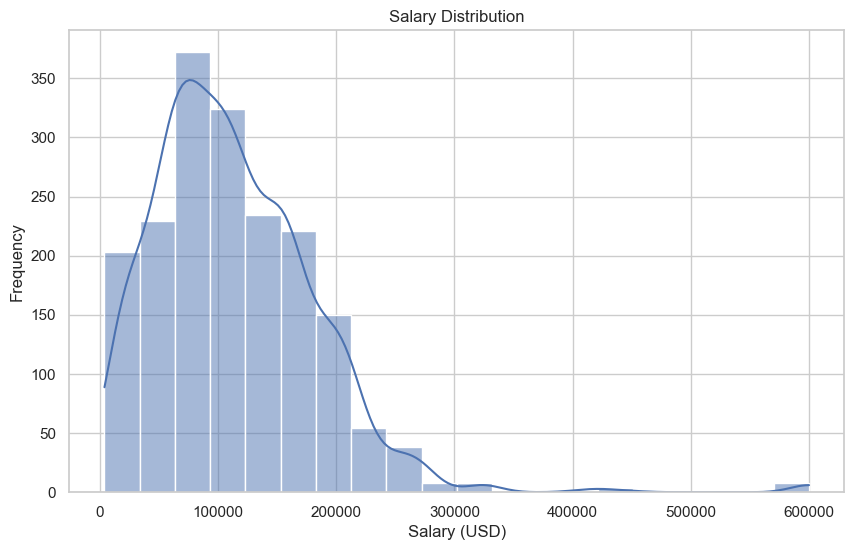

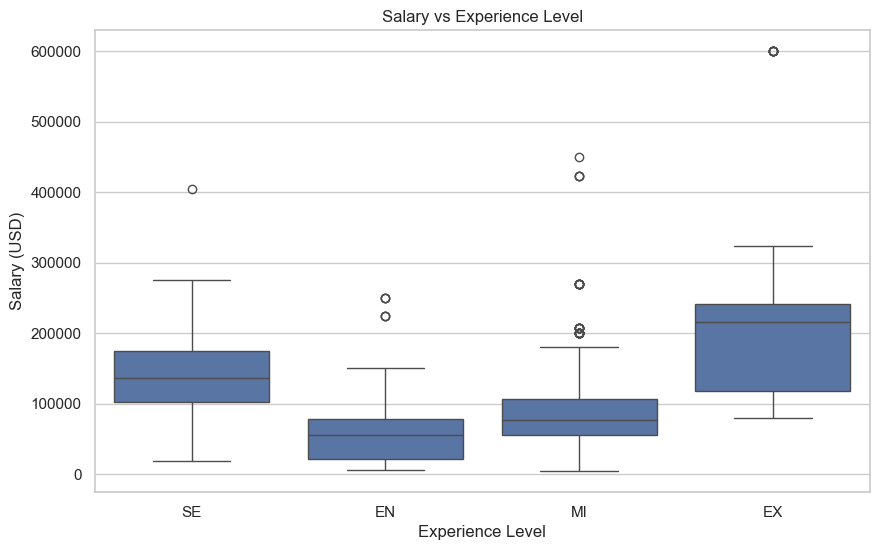

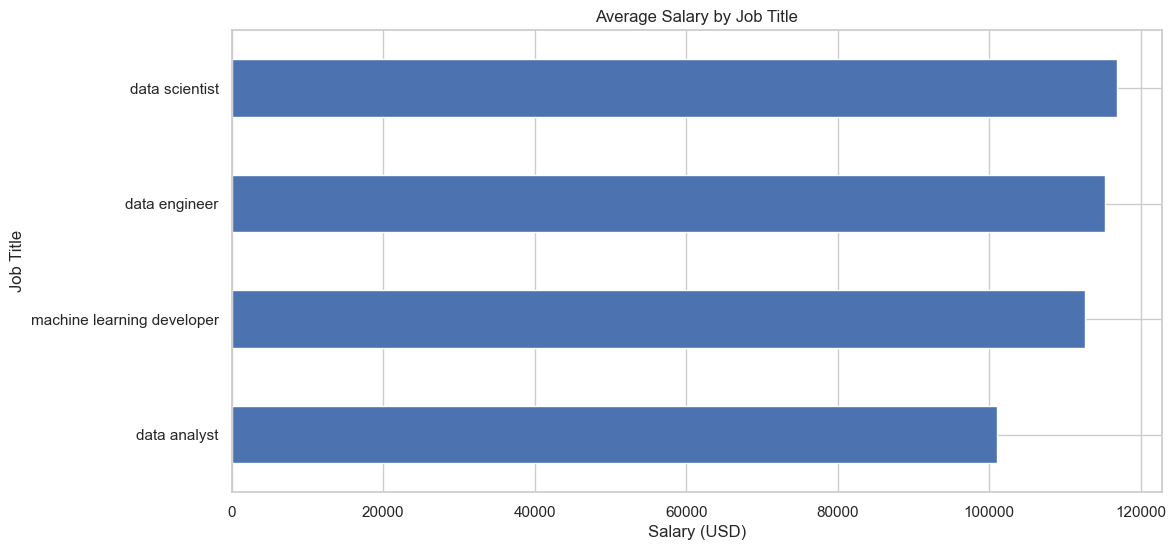

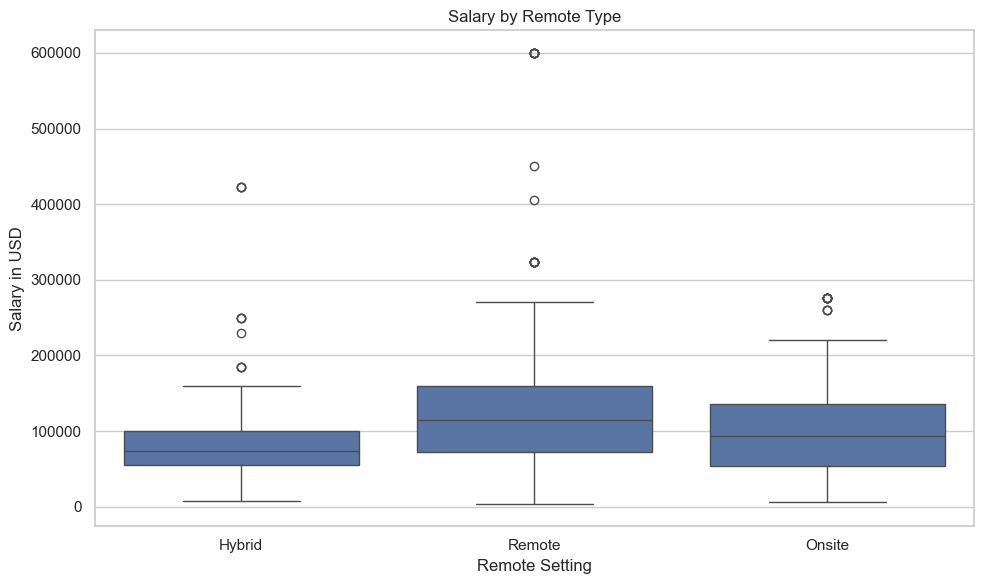

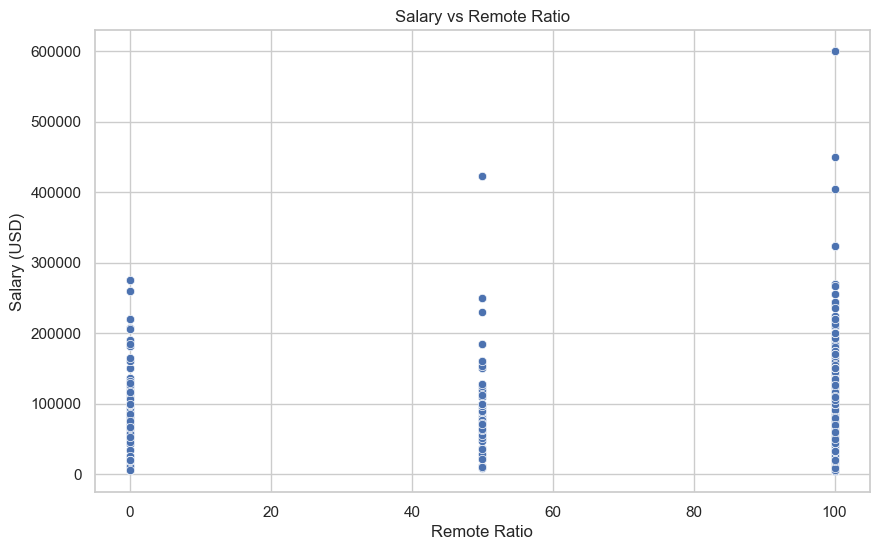

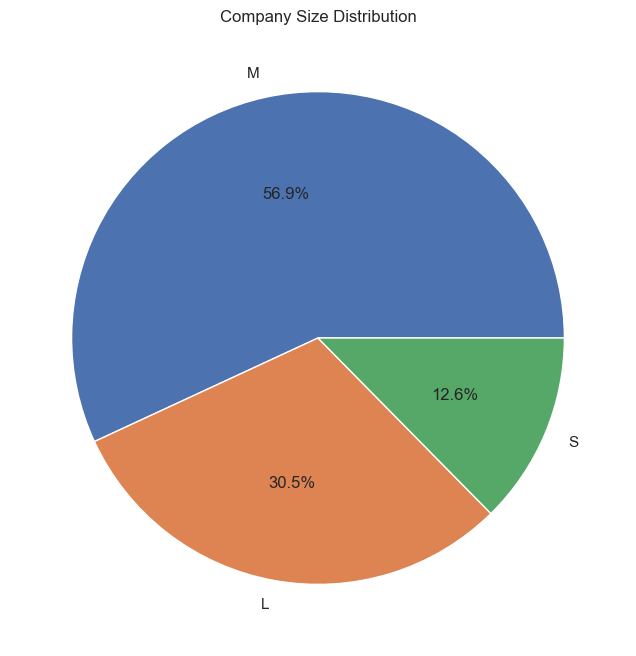

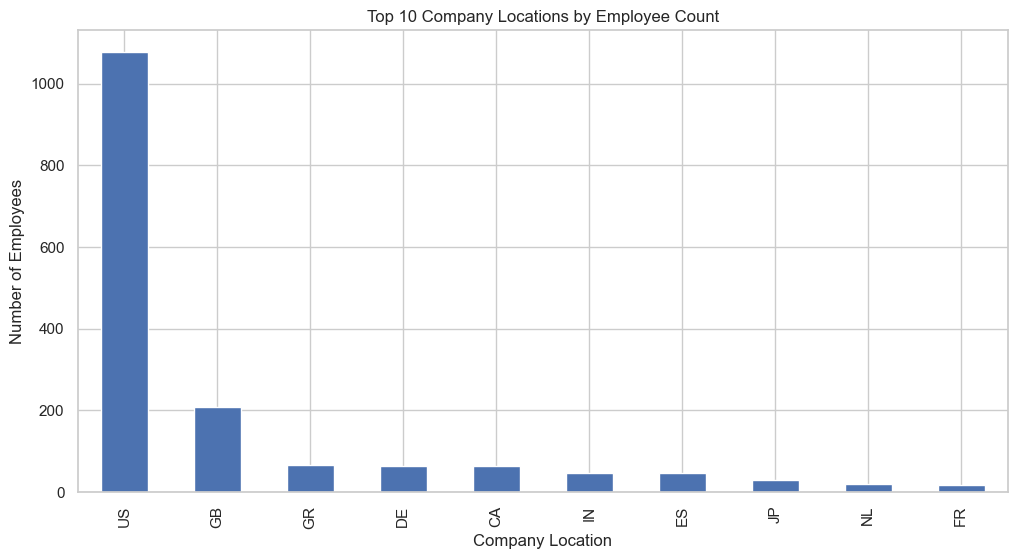

<Figure size 1000x600 with 0 Axes>

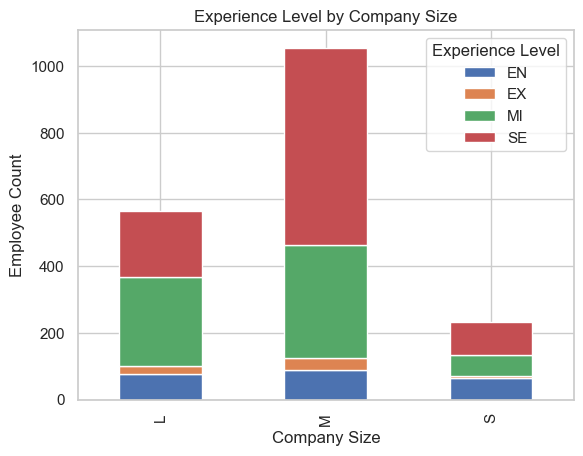


Top 15 Meaningful Skills:
skills
blockchain    32
finance       23
security      15
javascript    15
cloud         14
analytics     11
backend       10
testing       10
saas           9
frontend       8
bank           7
devops         7
salesforce     7
fintech        7
web            7
Name: count, dtype: int64


C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_40700\3999451815.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette='deep')


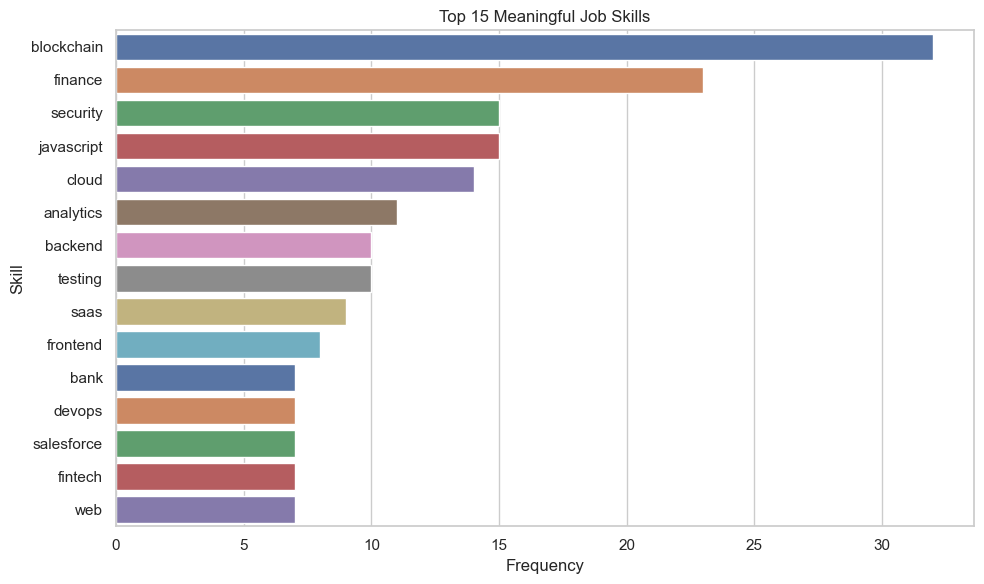

In [56]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import get_close_matches
import os

# --- Configurations ---
API_URL = "https://remoteok.com/api"
API_DATA_FILE = r"C:\Users\Mahmoud Gobran\Downloads\remoteok_api_data.csv"
MERGED_DATA_FILE = r"C:\Users\Mahmoud Gobran\Downloads\merged_salary_data.csv"
SALARY_CSV_FILE = r"C:\Users\Mahmoud Gobran\Downloads\salary_dataset.csv"

# --- Step 1: Fetch new API data ---
response = requests.get(API_URL)
data = response.json()
df_api_new = pd.DataFrame(data[1:])

# --- Step 2: Process API data ---
df_api_new = df_api_new[[
    'date', 'company', 'position', 'location', 'tags',
    'salary_min', 'salary_max'
]].copy()

df_api_new.rename(columns={
    'position': 'job_title',
    'tags': 'skills',
}, inplace=True)

df_api_new['date'] = pd.to_datetime(df_api_new['date'], errors='coerce')
df_api_new['salary_min'] = pd.to_numeric(df_api_new['salary_min'], errors='coerce')
df_api_new['salary_max'] = pd.to_numeric(df_api_new['salary_max'], errors='coerce')

# --- Step 3: Load existing API data if exists and append new data ---
if os.path.exists(API_DATA_FILE):
    df_api_old = pd.read_csv(API_DATA_FILE)
    df_api_old['date'] = pd.to_datetime(df_api_old['date'], errors='coerce')
    df_api_old['salary_min'] = pd.to_numeric(df_api_old['salary_min'], errors='coerce')
    df_api_old['salary_max'] = pd.to_numeric(df_api_old['salary_max'], errors='coerce')
    
    df_api = pd.concat([df_api_old, df_api_new], ignore_index=True)
    df_api.drop_duplicates(subset=['date', 'company', 'job_title'], inplace=True)
else:
    df_api = df_api_new.copy()

# --- Step 4: Save updated API data ---
df_api.to_csv(API_DATA_FILE, index=False)

# --- Step 5: Load salary CSV dataset ---
df_salary = pd.read_csv(SALARY_CSV_FILE)

# --- Step 6: Normalize job titles in both datasets ---
df_api['job_title'] = df_api['job_title'].str.lower().str.strip().str.replace('-', ' ')
df_salary['job_title'] = df_salary['job_title'].str.lower().str.strip().str.replace('-', ' ')

# --- Step 7: Fuzzy match job titles ---
api_titles = df_api['job_title'].unique()
salary_titles = df_salary['job_title'].unique()

job_title_map = {}

for title in api_titles:
    match = get_close_matches(title, salary_titles, n=1, cutoff=0.6)
    if match:
        job_title_map[title] = match[0]

df_api['job_title'] = df_api['job_title'].replace(job_title_map)

# --- Step 8: Merge API and salary datasets ---
df_api['job_title'] = df_api['job_title'].str.lower().str.strip()
df_salary['job_title'] = df_salary['job_title'].str.lower().str.strip()

df_merged = pd.merge(df_api, df_salary, on='job_title', how='inner')

# --- Step 9: Save merged dataset for future use ---
df_merged.to_csv(MERGED_DATA_FILE, index=False)

# --- Step 10: Data inspection and summary prints ---
print("Job title counts in merged data:")
print(df_merged['job_title'].value_counts())

print("Merged dataset shape:", df_merged.shape)
print("First 5 rows:")
print(df_merged.head())

print("\nColumn info:")
print(df_merged.info())

print("\nMissing values:")
print(df_merged.isnull().sum())

print("\nNumerical stats:")
print(df_merged.describe())

categorical_cols = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]
for col in categorical_cols:
    print(f"\n{col} values:")
    print(df_merged[col].unique())

print("\nUnique Job Titles:")
print(df_merged['job_title'].unique())

print("\nSalary Range by Job Title:")
print(df_merged.groupby('job_title')['salary_in_usd'].agg(['min', 'max']))

print("\nAverage Salary by Experience:")
print(df_merged.groupby('experience_level')['salary_in_usd'].mean())

print("\nEmployee Count by Company Size:")
print(df_merged['company_size'].value_counts())

print("\nAverage Remote Ratio:")
print(df_merged['remote_ratio'].mean())

print("\nTop 5 Countries by Employee Count:")
print(df_merged['employee_residence'].value_counts().head(5))

print("\nSalary vs Remote Ratio Correlation:")
print(df_merged['salary_in_usd'].corr(df_merged['remote_ratio']))

print("\nAverage Salary by Company Location:")
print(df_merged.groupby('company_location')['salary_in_usd'].mean())

print("\nExperience Level Distribution:")
print(df_merged['experience_level'].value_counts())

print("\nAverage Salary by Job Title:")
print(df_merged.groupby('job_title')['salary_in_usd'].mean())

# --- Step 11: Visualizations ---

plt.figure(figsize=(10, 6))
sns.histplot(df_merged['salary_in_usd'], bins=20, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df_merged)
plt.title('Salary vs Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.show()

plt.figure(figsize=(12, 6))
df_salary.groupby('job_title')['salary_in_usd'].mean().sort_values().plot(kind='barh')
plt.title('Average Salary by Job Title')
plt.xlabel('Salary (USD)')
plt.ylabel('Job Title')
plt.show()

remote_map = {0: 'Onsite', 50: 'Hybrid', 100: 'Remote'}
df_merged['remote_type'] = df_merged['remote_ratio'].map(remote_map)

plt.figure(figsize=(10,6))
sns.boxplot(data=df_merged, x='remote_type', y='salary_in_usd')
plt.title('Salary by Remote Type')
plt.xlabel('Remote Setting')
plt.ylabel('Salary in USD')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='remote_ratio', y='salary_in_usd', data=df_merged)
plt.title('Salary vs Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Salary (USD)')
plt.show()

plt.figure(figsize=(8, 8))
df_merged['company_size'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Company Size Distribution')
plt.ylabel('')
plt.show()

plt.figure(figsize=(12, 6))
df_merged['company_location'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Company Locations by Employee Count')
plt.xlabel('Company Location')
plt.ylabel('Number of Employees')
plt.show()

plt.figure(figsize=(10, 6))
pd.crosstab(df_merged['company_size'], df_merged['experience_level']).plot(kind='bar', stacked=True)
plt.title('Experience Level by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Employee Count')
plt.legend(title='Experience Level')
plt.show()

# --- Step 12: Skills Analysis ---

all_skills = df_api['skills'].dropna().explode()
all_skills = all_skills.str.lower().str.strip()

junk_skills = set([
    'remote', 'job', 'full time', 'full-time', 'contract', 'part time', 'digital nomad',
    'management', 'manager', 'lead', 'leader', 'non tech', 'technical', 'support', 
    'developer', 'engineer', 'engineering', 'software', 'consulting', 'admin', 'growth', 'dev',
    'senior', 'operations', 'training', 'sales', 'strategy', 'health', 'content', 'marketing',
    'finance', 'design', 'code', 'system', 'travel', 'operational', 'legal', 'voice', 'education'
])

filtered_skills = all_skills[~all_skills.isin(junk_skills)]

skill_map = {
    'js': 'javascript',
    'py': 'python',
    'node': 'nodejs',
    'reactjs': 'react',
    'typescript': 'javascript',
    'html5': 'html',
    'css3': 'css',
    'amazon': 'aws',
    'heroku': 'cloud',
    'web3': 'blockchain',
    'crypto': 'blockchain',
    'cryptocurrency': 'blockchain',
    'defi': 'blockchain',
    'investment': 'finance',
    'financial': 'finance'
}
filtered_skills = filtered_skills.replace(skill_map)

top_skills = filtered_skills.value_counts().head(15)

print("\nTop 15 Meaningful Skills:")
print(top_skills)

plt.figure(figsize=(10,6))
sns.barplot(x=top_skills.values, y=top_skills.index, palette='deep')
plt.title("Top 15 Meaningful Job Skills")
plt.xlabel("Frequency")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()
